In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fim import apriori, fpgrowth
from sklearn.metrics import classification_report

#### Loading the data

We load both the train and test sets produced by the data preparation notebook. Association rules are mined **only on the training set** — mining on the full dataset (train + test) and then evaluating a rule chosen from those same patterns would be a form of data leakage, since the "model" (the rule) would have been picked using information from the rows it's later tested on. The test set is only used once, at the very end, to evaluate a specific rule on data it has never contributed to.

In [2]:
train_path = "../data/cleaned_train.csv"
test_path = "../data/cleaned_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [3]:
train_df.columns

Index(['BGGId', 'Name', 'YearPublished', 'GameWeight', 'MinPlayers',
       'MaxPlayers', 'ComAgeRec', 'ComMinPlaytime', 'ComMaxPlaytime',
       'IsReimplementation', 'Kickstarted', 'Score_strategygames',
       'Score_abstracts', 'Score_familygames', 'Score_thematic', 'Score_cgs',
       'Score_wargames', 'Score_partygames', 'Score_childrensgames', 'Rating',
       'Avg_popularity_log', 'NumAlternates_log', 'NumImplementations_log',
       'NumExpansions_log', 'NumWeightVotes_log'],
      dtype='str')

In [4]:
train_df.describe()

,BGGId,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,ComMinPlaytime,ComMaxPlaytime,IsReimplementation,Kickstarted,...,Score_cgs,Score_wargames,Score_partygames,Score_childrensgames,Rating,Avg_popularity_log,NumAlternates_log,NumImplementations_log,NumExpansions_log,NumWeightVotes_log
count,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,...,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000,15779.000000
mean,118310.887382,2007.416313,1.991497,1.999493,4.646175,9.934406,51.194150,63.696907,0.117751,0.160720,...,0.000344,0.000352,0.000333,0.000407,1.891375,5.163085,0.502160,0.182312,0.352586,2.637336
std,104118.614399,12.607525,0.754835,0.635095,2.176133,2.897509,46.625506,56.052764,0.322324,0.367284,...,0.010041,0.009364,0.009166,0.010146,0.735437,1.370069,0.717137,0.363425,0.720968,1.346322
min,2.000000,1950.000000,1.000000,1.000000,1.000000,2.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.203973,0.000000,0.000000,0.000000,0.693147
25%,12853.500000,2003.000000,1.333300,2.000000,4.000000,8.000000,20.000000,30.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,4.143135,0.000000,0.000000,0.000000,1.609438
50%,110511.000000,2012.000000,2.000000,2.000000,4.000000,10.000000,30.000000,45.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,4.907741,0.000000,0.000000,0.000000,2.397895
75%,206089.000000,2017.000000,2.500000,2.000000,6.000000,12.000000,60.000000,90.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,5.969560,0.693147,0.000000,0.693147,3.332205
max,349131.000000,2021.000000,5.000000,8.000000,16.000000,21.000000,250.000000,360.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,3.000000,10.982203,6.746412,3.663562,5.541264,8.945593


## Feature and Pattern mining preprocessing

`qcut` splits values by quantiles (relative to this dataset's own distribution), while `cut` uses fixed thresholds that must be specified explicitly. We use `cut` where a fixed, real-world threshold makes sense (e.g. player counts, playtime), and `qcut` where we want bins that reflect the dataset's distribution (e.g. year published, popularity).

Any threshold estimated from the data (i.e. from `qcut`) is fit on the **training set only** and then applied to the test set using the same cut points — otherwise the bin edges themselves would leak information from the test set.

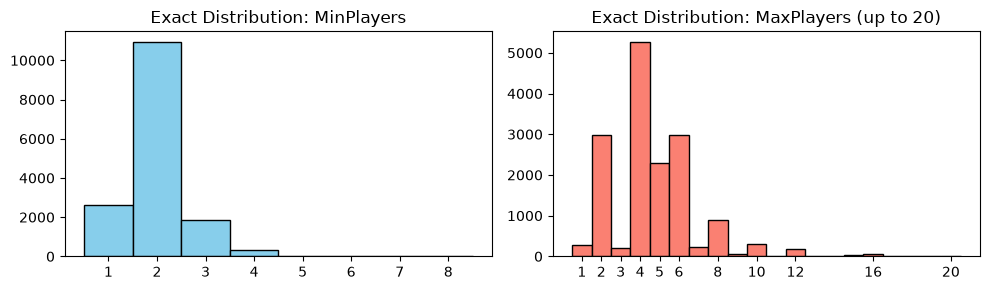

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(train_df['MinPlayers'], bins=range(1, 10), align='left', edgecolor='black', color='skyblue')
axes[0].set_title('Exact Distribution: MinPlayers')
axes[0].set_xticks(range(1, 9))

axes[1].hist(train_df['MaxPlayers'], bins=range(1, 22), align='left', edgecolor='black', color='salmon')
axes[1].set_title('Exact Distribution: MaxPlayers (up to 20)')
axes[1].set_xticks([1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20])

plt.tight_layout()
plt.show()

In [6]:
# Fixed, domain-based thresholds (not derived from the data) -> safe to apply to train and test
# directly. We use +inf as the top edge instead of train_df['MaxPlayers'].max() so that any test
# value larger than anything seen in train still falls into the last bin instead of becoming NaN.
maxplayers_bins = [0, 2, 4, 8, np.inf]
maxplayers_labels = ['Solo/Duo', 'SmallGroup', 'MidGroup', 'Large/Party']

for d in (train_df, test_df):
    d["MaxPlayersBin"] = pd.cut(d['MaxPlayers'], bins=maxplayers_bins, labels=maxplayers_labels)

print(train_df['MaxPlayersBin'].value_counts())

MaxPlayersBin
MidGroup       6421
SmallGroup     5467
Solo/Duo       3254
Large/Party     637
Name: count, dtype: int64


In [7]:
minplayers_bins = [0, 1, 2, np.inf]
minplayers_labels = ['Solo Friendly', 'Duo', 'Group']

for d in (train_df, test_df):
    d["MinPlayersBin"] = pd.cut(d['MinPlayers'], bins=minplayers_bins, labels=minplayers_labels)

print(train_df['MinPlayersBin'].value_counts())

MinPlayersBin
Duo              10933
Solo Friendly     2641
Group             2205
Name: count, dtype: int64


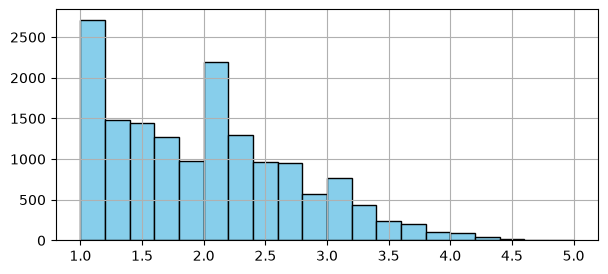

In [8]:
# Histogram of GameWeight
plt.figure(figsize=(7, 3))
train_df['GameWeight'].hist(bins=20, color='skyblue', edgecolor='black')
plt.show()

In [9]:
# Fixed thresholds on the BGG 1-5 weight scale (not quantiles): Easy = 1-2, Medium = 2-3, Hard = 3-5.
# The original code defined these bins but then called qcut (ignoring them, producing dataset-relative
# terciles instead of the intended fixed difficulty bands) — fixed here to actually use pd.cut with them.
weight_bins = [1, 2, 3, 5]
weight_labels = ['Easy', 'Medium', 'Hard']

for d in (train_df, test_df):
    d["WeightBin"] = pd.cut(d["GameWeight"], bins=weight_bins, labels=weight_labels)

print(train_df['WeightBin'].value_counts())

WeightBin
Easy      7425
Medium    5034
Hard      1527
Name: count, dtype: int64


In [10]:
# YearBin is quantile-based (data-relative "Old"/"Classic"/"Modern"/"New"), so the cut points are
# fit on the TRAIN set only, then applied identically to the test set.
_, year_edges = pd.qcut(train_df["YearPublished"], 4, labels=["Old", "Classic", "Modern", "New"], retbins=True)
year_edges[0], year_edges[-1] = -np.inf, np.inf

for d in (train_df, test_df):
    d["YearBin"] = pd.cut(d["YearPublished"], bins=year_edges, labels=["Old", "Classic", "Modern", "New"])

print(train_df["YearBin"].value_counts())
print(f"Cut points used (fit on train): {year_edges}")

YearBin
Old        4239
Classic    4234
Modern     4213
New        3093
Name: count, dtype: int64
Cut points used (fit on train): [ -inf 2003. 2012. 2017.   inf]


We only use `ComMaxPlaytime` (not `ComMinPlaytime`) to avoid redundant rules: a game with a high maximum playtime is already a long game, so both variables would carry very similar information for pattern mining.

In [11]:
# 0-30: Short, 30-60: Medium, 60-120: Long, 120+: VeryLong (fixed thresholds, safe for both sets)
playtime_bins = [0, 30, 60, 120, np.inf]
playtime_labels = ['Short(<30m)', 'Medium(30-60m)', 'Long(60-120m)', 'VeryLong(>120m)']

for d in (train_df, test_df):
    d['PlaytimeBin'] = pd.cut(d['ComMaxPlaytime'], bins=playtime_bins, labels=playtime_labels)

print(train_df['PlaytimeBin'].value_counts().sort_index())

PlaytimeBin
Short(<30m)        6350
Medium(30-60m)     5027
Long(60-120m)      3041
VeryLong(>120m)    1361
Name: count, dtype: int64


In [12]:
# PopularityBin is quantile-based, so fit on train only and applied to test with the same edges.
_, pop_edges = pd.qcut(train_df["Avg_popularity_log"], 3, labels=["LowPop", "MedPop", "HighPop"], retbins=True)
pop_edges[0], pop_edges[-1] = -np.inf, np.inf

for d in (train_df, test_df):
    d["PopularityBin"] = pd.cut(d["Avg_popularity_log"], bins=pop_edges, labels=["LowPop", "MedPop", "HighPop"])

print(train_df["PopularityBin"].value_counts())

PopularityBin
LowPop     5272
HighPop    5257
MedPop     5250
Name: count, dtype: int64


In [13]:
# Fixed threshold (has at least one expansion or not) -> safe for both sets
for d in (train_df, test_df):
    d["HasExpansions"] = d["NumExpansions_log"].apply(lambda x: 1 if x > 0 else 0)

print(train_df["HasExpansions"].value_counts())

HasExpansions
0    11590
1     4189
Name: count, dtype: int64


Binarizing the `Score_*` variables: a value greater than 0 means the game is ranked at all in that BGG subdomain.

In [14]:
score_cols = [
    'Score_strategygames', 'Score_abstracts', 'Score_familygames',
    'Score_thematic', 'Score_cgs', 'Score_wargames',
    'Score_partygames', 'Score_childrensgames'
]

# Fixed threshold (score > 0) -> safe for both sets
for col in score_cols:
    new_name = 'Is_' + col.replace('Score_', '')
    for d in (train_df, test_df):
        d[new_name] = (d[col] > 0).astype(int)

# How many games fall into each sub-domain (train set)
print(train_df[[f'Is_{c.replace("Score_", "")}' for c in score_cols]].sum())

Is_strategygames     1799
Is_abstracts          812
Is_familygames       1844
Is_thematic           953
Is_cgs                238
Is_wargames          2251
Is_partygames         471
Is_childrensgames     654
dtype: int64


In [15]:
for d in (train_df, test_df):
    d['Rating'] = d['Rating'].astype('category')

Careful with `min_support`: too high a threshold (e.g. 5%) would make the algorithm ignore CGS, Party Games, and probably Children's Games entirely, since these subdomains are inherently small (see counts above).

## Pattern Mining

## Apriori

In [16]:
# Final feature list for mining
mining_features = [
    'Rating',
    'MinPlayersBin',
    'MaxPlayersBin',
    'WeightBin',
    'YearBin',
    'PlaytimeBin',
    'PopularityBin',
    'HasExpansions',
    'Is_strategygames', 'Is_abstracts', 'Is_familygames',
    'Is_thematic', 'Is_cgs', 'Is_wargames',
    'Is_partygames', 'Is_childrensgames'
]

# One-hot encode the TRAINING set only, for mining
train_mining_df = pd.get_dummies(train_df[mining_features], prefix_sep="_")
print(f"Total number of items: {train_mining_df.shape[1]}")

# The one-hot encoded dataframe is converted into a transaction-based representation by selecting,
# for each instance, the active features (value == 1), as required by the Apriori algorithm.
transactions = train_mining_df.apply(
    lambda row: row[row == 1].index.tolist(),
    axis=1
).tolist()

Total number of items: 33


In [17]:
help(apriori)

Help on built-in function apriori in module fim:

apriori(...)
    apriori (tracts, target='s', supp=10, zmin=1, zmax=None, report='a',
             eval='x', agg='x', thresh=10, prune=None, algo='b', mode='',
             border=None)
    Find frequent item sets with the Apriori algorithm.
    tracts  transaction database to mine (mandatory)
            The database must be an iterable of transactions;
            each transaction must be an iterable of items;
            each item must be a hashable object.
            If the database is a dictionary, the transactions are
            the keys, the values their (integer) multiplicities.
    target  type of frequent item sets to find     (default: s)
            s/a   sets/all   all     frequent item sets
            c     closed     closed  frequent item sets
            m     maximal    maximal frequent item sets
            g     gens       generators
            r     rules      association rules
    supp    minimum support of an i

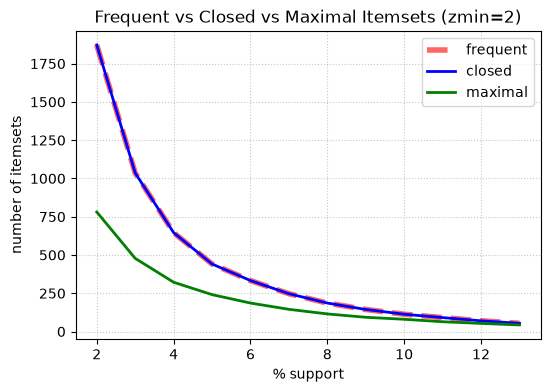

In [18]:
len_fr_it = []
len_cl_it = []
len_max_it = []
max_supp = 14
x_range = np.arange(2, max_supp)

for i in x_range:
    fr_itemsets = apriori(transactions, target="s", supp=i, zmin=2)
    cl_itemsets = apriori(transactions, target="c", supp=i, zmin=2)
    max_itemsets = apriori(transactions, target="m", supp=i, zmin=2)

    len_fr_it.append(len(fr_itemsets))
    len_cl_it.append(len(cl_itemsets))
    len_max_it.append(len(max_itemsets))

plt.figure(figsize=(6, 4))
plt.plot(x_range, len_fr_it, label="frequent", color='red', linestyle='--', linewidth=4, alpha=0.6)
plt.plot(x_range, len_cl_it, label="closed", color='blue', linewidth=2)
plt.plot(x_range, len_max_it, label="maximal", color='green', linewidth=2)

plt.legend()
plt.xlabel("% support")
plt.ylabel("number of itemsets")
plt.title("Frequent vs Closed vs Maximal Itemsets (zmin=2)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

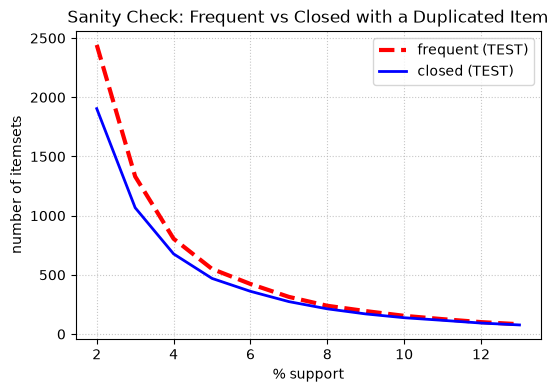

In [19]:
# Sanity check: duplicate one item and verify that frequent/closed itemsets diverge once an item
# is no longer "closed" (i.e. has a duplicate with identical support) — validates that the earlier
# overlap between frequent and closed curves reflects a real property of the data, not a bug.
item_to_duplicate = transactions[0][0]
duplicated_item = str(item_to_duplicate) + "_DUP"

transactions_test = []
for t in transactions:
    new_t = list(t)
    if item_to_duplicate in t:
        new_t.append(duplicated_item)
    transactions_test.append(tuple(new_t))

len_fr_test = []
len_cl_test = []
max_supp = 14
x_range = np.arange(2, max_supp)

for i in x_range:
    fr = apriori(transactions_test, target="s", supp=i, zmin=1)
    cl = apriori(transactions_test, target="c", supp=i, zmin=1)
    len_fr_test.append(len(fr))
    len_cl_test.append(len(cl))

plt.figure(figsize=(6, 4))
plt.plot(x_range, len_fr_test, label="frequent (TEST)", color='red', linestyle='--', linewidth=3)
plt.plot(x_range, len_cl_test, label="closed (TEST)", color='blue', linewidth=2)

plt.legend()
plt.xlabel("% support")
plt.ylabel("number of itemsets")
plt.title("Sanity Check: Frequent vs Closed with a Duplicated Item")
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

#### Itemset structure: Frequent, Closed and Maximal

Looking at the plots above:

1. **Frequent and Closed itemsets overlap almost perfectly** across the support range tested. This means every frequent itemset is also closed — i.e. no itemset has exactly the same support as one of its supersets, and adding any new element to an existing combination always reduces support at least slightly (items don't co-occur "in lockstep").
2. **Maximal itemsets are consistently fewer** than closed ones: many closed sets are still not maximal, since they have supersets that also clear the support threshold.
3. **The sanity check above confirms this isn't a bug**: once an artificial duplicate item is introduced, the frequent and closed curves visibly separate, because the original item stops being "closed" (it now has a same-support duplicate). Since the real data doesn't show this separation, the overlap we observe is a genuine property of the dataset, not a measurement error.

### Frequent itemsets

In [20]:
supp = 5
zmin = 2

In [21]:
frequent_itemsets = apriori(transactions, target="s", supp=supp, zmin=zmin, report="S")
print(f"Frequent itemsets found: {len(frequent_itemsets)}.")
pd.DataFrame(frequent_itemsets, columns=["frequent_itemset", "support"])

Frequent itemsets found: 441.


,frequent_itemset,support
0,"(PlaytimeBin_VeryLong(>120m), Is_wargames)",5.298181
1,"(PlaytimeBin_VeryLong(>120m), MinPlayersBin_Duo)",5.653083
2,"(WeightBin_Hard, Rating_3)",5.621396
3,"(WeightBin_Hard, MinPlayersBin_Duo)",6.337537
4,"(Is_strategygames, HasExpansions)",5.539008
...,...,...
436,"(MaxPlayersBin_MidGroup, MinPlayersBin_Duo)",24.925534
437,"(Rating_2, WeightBin_Easy)",21.864503
438,"(Rating_2, WeightBin_Easy, MinPlayersBin_Duo)",14.779137
439,"(Rating_2, MinPlayersBin_Duo)",30.641993


### Closed itemsets

In [22]:
cl_itemsets = apriori(transactions, target="c", supp=supp, zmin=zmin, report="S")
print(f"Closed itemsets found: {len(cl_itemsets)}.")
pd.DataFrame(cl_itemsets, columns=["closed_itemset", "support"])

Closed itemsets found: 441.


,closed_itemset,support
0,"(PlaytimeBin_VeryLong(>120m), Is_wargames)",5.298181
1,"(PlaytimeBin_VeryLong(>120m), MinPlayersBin_Duo)",5.653083
2,"(WeightBin_Hard, Rating_3)",5.621396
3,"(WeightBin_Hard, MinPlayersBin_Duo)",6.337537
4,"(Is_strategygames, HasExpansions)",5.539008
...,...,...
436,"(MaxPlayersBin_MidGroup, MinPlayersBin_Duo)",24.925534
437,"(Rating_2, WeightBin_Easy)",21.864503
438,"(Rating_2, WeightBin_Easy, MinPlayersBin_Duo)",14.779137
439,"(Rating_2, MinPlayersBin_Duo)",30.641993


### Maximal itemsets

In [23]:
max_itemsets = apriori(transactions, target="m", supp=supp, zmin=zmin, report="S")
print(f"Maximal itemsets found: {len(max_itemsets)}.")
pd.DataFrame(max_itemsets, columns=["maximal_itemset", "support"])

Maximal itemsets found: 241.


,maximal_itemset,support
0,"(PlaytimeBin_VeryLong(>120m), Is_wargames)",5.298181
1,"(PlaytimeBin_VeryLong(>120m), MinPlayersBin_Duo)",5.653083
2,"(WeightBin_Hard, Rating_3)",5.621396
3,"(WeightBin_Hard, MinPlayersBin_Duo)",6.337537
4,"(Is_strategygames, HasExpansions)",5.539008
...,...,...
236,"(PopularityBin_HighPop, Rating_2, WeightBin_Ea...",5.488307
237,"(PlaytimeBin_Short(<30m), MaxPlayersBin_MidGro...",5.684771
238,"(PlaytimeBin_Short(<30m), MaxPlayersBin_MidGro...",7.624057
239,"(PlaytimeBin_Short(<30m), Rating_2, WeightBin_...",9.246467


Support plots

Support vs number of itemsets

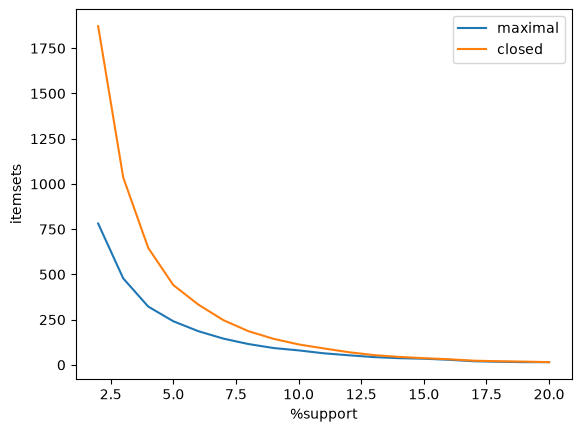

In [24]:
len_max_it = []
len_cl_it = []
max_supp = 21
for i in range(2, max_supp):
    max_itemsets = apriori(transactions, target="m", supp=i, zmin=zmin)
    cl_itemsets = apriori(transactions, target="c", supp=i, zmin=zmin)
    len_max_it.append(len(max_itemsets))
    len_cl_it.append(len(cl_itemsets))

plt.plot(np.arange(2, max_supp), len_max_it, label="maximal")
plt.plot(np.arange(2, max_supp), len_cl_it, label="closed")
plt.legend()
plt.xlabel("%support")
plt.ylabel("itemsets")
plt.show()

**Where's the "signal" in the noise?** Below a certain support level there is typically a very large number of patterns — mostly "noise": overly specific combinations that only apply to a handful of games. As support increases, both curves flatten out sharply; that's usually the "sweet spot" where closed and maximal itemsets drop to a manageable number, making it easier to find patterns that are both frequent and meaningful. Use the plot above (on your actual data) to identify where that flattening happens, rather than assuming a fixed support value.

Support vs number of itemsets for HasExpansions -> With / Without

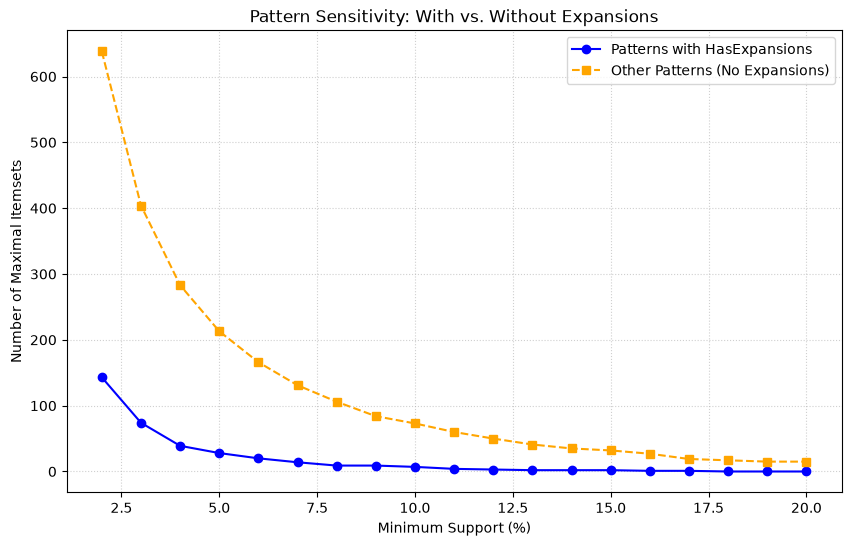

In [25]:
# Lists to store the counts
with_exp_count = []
without_exp_count = []
target_feature = "HasExpansions"
max_supp = 21

for i in range(2, max_supp):
    max_itemsets = apriori(transactions, target="m", supp=i, zmin=zmin)
    with_exp = [item for item, supp in max_itemsets if any(target_feature in x for x in item)]
    without_exp = [item for item, supp in max_itemsets if not any(target_feature in x for x in item)]
    with_exp_count.append(len(with_exp))
    without_exp_count.append(len(without_exp))

plt.figure(figsize=(10, 6))
supports = np.arange(2, max_supp)
plt.plot(supports, with_exp_count, marker='o', label=f"Patterns with {target_feature}", color="blue")
plt.plot(supports, without_exp_count, marker='s', label="Other Patterns (No Expansions)", color="orange", linestyle="--")

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel("Minimum Support (%)")
plt.ylabel("Number of Maximal Itemsets")
plt.title("Pattern Sensitivity: With vs. Without Expansions")
plt.show()

In [26]:
# Extract Maximal Itemsets at a chosen support and inspect the ones involving HasExpansions
min_supp = 5
max_itemsets = apriori(transactions, target="m", supp=min_supp, zmin=2, report="S")

target_feature = "HasExpansions"
yes_patterns = [
    {"Pattern": ", ".join(item), "Support %": f"{round(supp, 2)}%"}
    for item, supp in max_itemsets
    if any(target_feature in x for x in item)
]

if yes_patterns:
    df_yes_patterns = pd.DataFrame(yes_patterns).sort_values("Support %", ascending=False)
    print(f"--- Top Maximal Patterns for Games with Expansions (Support > {min_supp}%) ---")
    print(f"({len(df_yes_patterns)} patterns found)")
    pd.set_option('display.max_colwidth', None)
    print(df_yes_patterns.to_string(index=False))
else:
    print(f"No patterns found containing '{target_feature}' at {min_supp}% support.")

--- Top Maximal Patterns for Games with Expansions (Support > 5%) ---
(28 patterns found)
                                                         Pattern Support %
         HasExpansions, PopularityBin_HighPop, MinPlayersBin_Duo     9.84%
                      HasExpansions, Rating_2, MinPlayersBin_Duo     8.21%
                  Rating_3, HasExpansions, PopularityBin_HighPop     7.69%
              HasExpansions, WeightBin_Medium, MinPlayersBin_Duo     7.38%
                             HasExpansions, PopularityBin_MedPop     7.25%
                        PlaytimeBin_Long(60-120m), HasExpansions     7.24%
          HasExpansions, WeightBin_Medium, PopularityBin_HighPop     7.19%
                                      YearBin_New, HasExpansions     7.03%
                  HasExpansions, PopularityBin_HighPop, Rating_2     6.96%
      HasExpansions, MaxPlayersBin_SmallGroup, MinPlayersBin_Duo     6.79%
    HasExpansions, PopularityBin_HighPop, MaxPlayersBin_MidGroup     6.73%
          

### Rules extraction

In [27]:
# Run FP-Growth (via fim's apriori with target='r') to generate association rules from the
# one-hot encoded transactions (training set only)
supp = 5   # minimum support (%)
conf = 70  # minimum confidence (%)
report = 'aScl'  # include absolute support, % support, confidence and lift in the results

rules = apriori(transactions, target='r', supp=supp, conf=conf, report=report)

rules_df = pd.DataFrame(
    rules,
    columns=["consequent", "antecedent", "abs_support", "%_support", "confidence", "lift"],
)
rules_df = rules_df.sort_values(by="lift", axis=0, ascending=False)

pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

print(f"Association rules found: {len(rules_df)}.")
rules_df

Association rules found: 198.


,consequent,antecedent,abs_support,%_support,confidence,lift
4,Is_wargames,"(PlaytimeBin_VeryLong(>120m), MinPlayersBin_Duo)",628,3.979973,0.704036,4.935132
47,MaxPlayersBin_Solo/Duo,"(Is_wargames, PopularityBin_MedPop, MinPlayersBin_Duo)",586,3.713797,0.741772,3.596934
48,MaxPlayersBin_Solo/Duo,"(Is_wargames, PopularityBin_MedPop)",785,4.974967,0.740566,3.591085
50,MaxPlayersBin_Solo/Duo,"(Is_wargames, WeightBin_Medium)",930,5.893910,0.700829,3.398396
5,PopularityBin_HighPop,"(Is_strategygames, HasExpansions)",781,4.949617,0.893593,2.682138
...,...,...,...,...,...,...
172,MinPlayersBin_Duo,"(WeightBin_Medium, MaxPlayersBin_SmallGroup)",1264,8.010647,0.702613,1.014042
187,MinPlayersBin_Duo,"(PopularityBin_HighPop, PlaytimeBin_Short(<30m))",1165,7.383231,0.701385,1.012270
197,MinPlayersBin_Duo,"(WeightBin_Easy,)",5206,32.993219,0.701145,1.011924
166,MinPlayersBin_Duo,"(PopularityBin_MedPop, PlaytimeBin_Short(<30m), Rating_2)",666,4.220800,0.701053,1.011791


### Histograms of Confidence and Lift

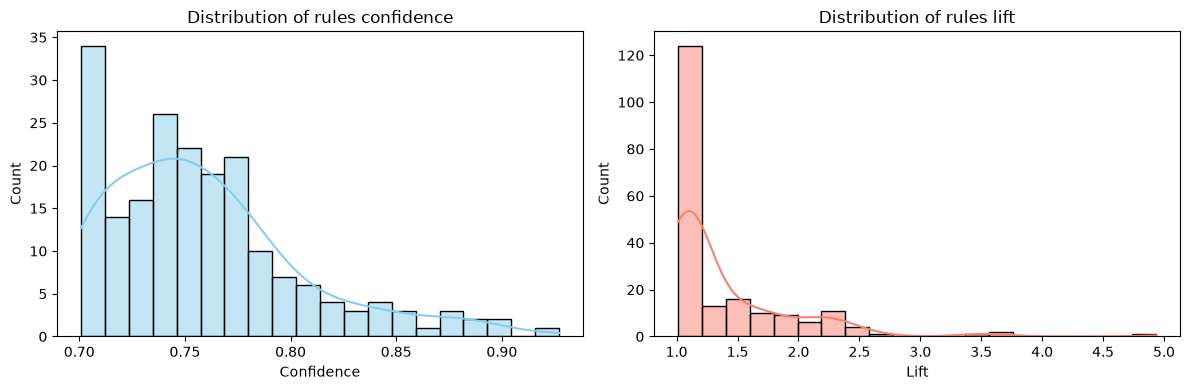

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(rules_df['confidence'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of rules confidence')
axes[0].set_xlabel('Confidence')

sns.histplot(rules_df['lift'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of rules lift')
axes[1].set_xlabel('Lift')

plt.tight_layout()
plt.show()

We keep only the rules where confidence(X → Y) > support(Y). This is mathematically equivalent to **lift > 1** (lift is defined as confidence divided by the consequent's support), so we can filter directly on the `lift` column already in `rules_df` instead of recomputing it manually.

In [29]:
rules_interesting = rules_df[rules_df['lift'] > 1]
print(f"{len(rules_interesting)} / {len(rules_df)} rules have lift > 1 (confidence beats the consequent's base rate).")
rules_interesting

198 / 198 rules have lift > 1 (confidence beats the consequent's base rate).


,consequent,antecedent,abs_support,%_support,confidence,lift
4,Is_wargames,"(PlaytimeBin_VeryLong(>120m), MinPlayersBin_Duo)",628,3.979973,0.704036,4.935132
47,MaxPlayersBin_Solo/Duo,"(Is_wargames, PopularityBin_MedPop, MinPlayersBin_Duo)",586,3.713797,0.741772,3.596934
48,MaxPlayersBin_Solo/Duo,"(Is_wargames, PopularityBin_MedPop)",785,4.974967,0.740566,3.591085
50,MaxPlayersBin_Solo/Duo,"(Is_wargames, WeightBin_Medium)",930,5.893910,0.700829,3.398396
5,PopularityBin_HighPop,"(Is_strategygames, HasExpansions)",781,4.949617,0.893593,2.682138
...,...,...,...,...,...,...
172,MinPlayersBin_Duo,"(WeightBin_Medium, MaxPlayersBin_SmallGroup)",1264,8.010647,0.702613,1.014042
187,MinPlayersBin_Duo,"(PopularityBin_HighPop, PlaytimeBin_Short(<30m))",1165,7.383231,0.701385,1.012270
197,MinPlayersBin_Duo,"(WeightBin_Easy,)",5206,32.993219,0.701145,1.011924
166,MinPlayersBin_Duo,"(PopularityBin_MedPop, PlaytimeBin_Short(<30m), Rating_2)",666,4.220800,0.701053,1.011791


Filtering by lift and support

In [30]:
s = 5
l = 1.5
rules_filtered = rules_df[(rules_df['%_support'] > s) & (rules_df['lift'] > l)].copy()
rules_filtered

,consequent,antecedent,abs_support,%_support,confidence,lift
50,MaxPlayersBin_Solo/Duo,"(Is_wargames, WeightBin_Medium)",930,5.893910,0.700829,3.398396
6,PopularityBin_HighPop,"(Is_strategygames, WeightBin_Medium)",889,5.634071,0.814849,2.445786
10,PopularityBin_HighPop,"(Is_strategygames,)",1454,9.214779,0.808227,2.425910
9,PopularityBin_HighPop,"(Is_strategygames, MinPlayersBin_Duo)",925,5.862222,0.806452,2.420582
17,PopularityBin_HighPop,"(Is_familygames, Rating_2)",832,5.272831,0.776119,2.329539
25,PopularityBin_HighPop,"(Is_familygames,)",1392,8.821852,0.754881,2.265791
24,PopularityBin_HighPop,"(Is_familygames, MinPlayersBin_Duo)",1023,6.483301,0.750550,2.252793
22,PopularityBin_HighPop,"(Is_familygames, WeightBin_Easy)",1042,6.603714,0.741110,2.224456
90,Rating_1,"(YearBin_Old, WeightBin_Easy, MinPlayersBin_Duo)",1103,6.990304,0.708869,2.143999
88,Rating_1,"(YearBin_Old, PlaytimeBin_Short(<30m), MinPlayersBin_Duo)",835,5.291844,0.703454,2.127622


Filtering to rules built only from closed itemsets

In [31]:
closed_sets = [set(itemset) for itemset, _ in cl_itemsets]

def to_itemset(x):
    return {x} if isinstance(x, str) else set(x)

def from_closed(row):
    ant = to_itemset(row['antecedent'])
    cons = to_itemset(row['consequent'])
    return any((ant | cons).issubset(cs) for cs in closed_sets)

rules_closed = rules_df[rules_df.apply(from_closed, axis=1)]
print(f"{len(rules_closed)} rules extracted")
rules_closed

6 rules extracted


,consequent,antecedent,abs_support,%_support,confidence,lift
101,MinPlayersBin_Duo,"(YearBin_Old,)",3270,20.723747,0.771408,1.113331
155,MinPlayersBin_Duo,"(Rating_1,)",3991,25.293111,0.764999,1.104081
180,MinPlayersBin_Duo,"(MaxPlayersBin_SmallGroup,)",4167,26.408518,0.762210,1.100055
141,MinPlayersBin_Duo,"(PopularityBin_LowPop,)",3912,24.792446,0.742033,1.070936
196,MinPlayersBin_Duo,"(PlaytimeBin_Short(<30m),)",4650,29.469548,0.732283,1.056865
197,MinPlayersBin_Duo,"(WeightBin_Easy,)",5206,32.993219,0.701145,1.011924


Analysis by consequent

In [32]:
# Most frequent consequents
rules_df['consequent'].value_counts()

consequent
MinPlayersBin_Duo          137
WeightBin_Easy              26
PopularityBin_HighPop       18
MaxPlayersBin_MidGroup       6
Rating_1                     4
MaxPlayersBin_Solo/Duo       3
PlaytimeBin_Short(<30m)      3
Is_wargames                  1
Name: count, dtype: int64

In [33]:
# consequent == Rating_1 (low rating)
rules_df[rules_df['consequent'] == 'Rating_1']

,consequent,antecedent,abs_support,%_support,confidence,lift
81,Rating_1,"(YearBin_Old, PopularityBin_LowPop, WeightBin_Easy)",623,3.948286,0.735537,2.224658
90,Rating_1,"(YearBin_Old, WeightBin_Easy, MinPlayersBin_Duo)",1103,6.990304,0.708869,2.143999
86,Rating_1,"(YearBin_Old, PlaytimeBin_Short(<30m), WeightBin_Easy, MinPlayersBin_Duo)",571,3.618734,0.707559,2.140037
88,Rating_1,"(YearBin_Old, PlaytimeBin_Short(<30m), MinPlayersBin_Duo)",835,5.291844,0.703454,2.127622


In [34]:
# consequent == Is_wargames
rules_df[rules_df['consequent'] == 'Is_wargames'].sort_values('lift', ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
4,Is_wargames,"(PlaytimeBin_VeryLong(>120m), MinPlayersBin_Duo)",628,3.979973,0.704036,4.935132


In [35]:
# consequent == WeightBin_Easy
rules_df[rules_df['consequent'] == 'WeightBin_Easy']

,consequent,antecedent,abs_support,%_support,confidence,lift
27,WeightBin_Easy,"(Is_familygames, PlaytimeBin_Short(<30m))",890,5.640408,0.927083,1.970161
185,WeightBin_Easy,"(PopularityBin_HighPop, PlaytimeBin_Short(<30m), MinPlayersBin_Duo)",967,6.128399,0.830043,1.763939
182,WeightBin_Easy,"(PopularityBin_HighPop, PlaytimeBin_Short(<30m), Rating_2)",798,5.057355,0.829522,1.762832
186,WeightBin_Easy,"(PopularityBin_HighPop, PlaytimeBin_Short(<30m))",1365,8.650738,0.821794,1.746409
29,WeightBin_Easy,"(Is_familygames, MaxPlayersBin_MidGroup)",743,4.708790,0.792956,1.685125
35,WeightBin_Easy,"(Is_familygames, MinPlayersBin_Duo)",1053,6.673427,0.772561,1.641782
36,WeightBin_Easy,"(Is_familygames,)",1406,8.910577,0.762473,1.620345
19,WeightBin_Easy,"(Is_familygames, PopularityBin_HighPop, MinPlayersBin_Duo)",780,4.943279,0.762463,1.620324
14,WeightBin_Easy,"(Is_familygames, PopularityBin_HighPop, Rating_2)",633,4.011661,0.760817,1.616826
32,WeightBin_Easy,"(Is_familygames, Rating_2)",814,5.158755,0.759328,1.613662


### Extraction of Specific Qualitative Rules for the Report

In [36]:
# Criteria for the 3 rules selected for the report
# Note: antecedents in fim's apriori output are tuples
selected_criteria = [
    {'cons': 'PlaytimeBin_Short(<30m)', 'ant': ('Is_abstracts',)},
    {'cons': 'PlaytimeBin_Short(<30m)', 'ant': ('WeightBin_Easy',)},  # fixed: was a plain string, not a 1-tuple
    {'cons': 'WeightBin_Hard', 'ant': ('Is_strategygames', 'HasExpansions')}
]

def is_selected(row):
    for criterion in selected_criteria:
        if row['consequent'] == criterion['cons'] and sorted(list(row['antecedent'])) == sorted(list(criterion['ant'])):
            return True
    return False

selected_qualitative_rules = rules_df[rules_df.apply(is_selected, axis=1)].copy()
selected_qualitative_rules = selected_qualitative_rules.sort_values(by="lift", ascending=False)

print("Selected Qualitative Rules for the Report:")
selected_qualitative_rules

Selected Qualitative Rules for the Report:


,consequent,antecedent,abs_support,%_support,confidence,lift
0,PlaytimeBin_Short(<30m),"(Is_abstracts,)",600,3.802522,0.738916,1.83612


### Classification

To turn an association rule into a simple classifier, we pick the rule with the highest lift whose consequent is `Is_wargames` (rather than a rule chosen by manually eyeballing a specific row, which is hard to reproduce), and evaluate it on the held-out **test set** — never seen during mining — to get a genuinely out-of-sample estimate of its performance.

In [37]:
# Apply the exact same preprocessing to the test set and align its columns to the training
# one-hot layout (in case some category doesn't appear at all in the test set)
test_mining_df = pd.get_dummies(test_df[mining_features], prefix_sep="_")
test_mining_df = test_mining_df.reindex(columns=train_mining_df.columns, fill_value=0)

wargames_rules = rules_df[rules_df['consequent'] == 'Is_wargames'].sort_values('lift', ascending=False)

if wargames_rules.empty:
    print("No association rule found with consequent 'Is_wargames' at the current supp/conf thresholds.")
else:
    top_rule = wargames_rules.iloc[0]
    ant = top_rule['antecedent']
    antecedent_rule = list(ant) if isinstance(ant, (tuple, list)) else [ant]

    print(f"Selected rule: {antecedent_rule} -> Is_wargames "
          f"(lift={top_rule['lift']:.2f}, confidence={top_rule['confidence']:.1f}%, "
          f"support={top_rule['%_support']:.2f}%, on TRAIN)")

    def predict_rule(row):
        return 1 if all(row[feature] == 1 for feature in antecedent_rule) else 0

    y_test = test_mining_df['Is_wargames']
    y_pred_rule = test_mining_df.drop(columns=['Is_wargames']).apply(predict_rule, axis=1)

    print("\nEvaluation on the held-out TEST set (not used for rule mining):")
    print(classification_report(y_test, y_pred_rule))

Selected rule: ['PlaytimeBin_VeryLong(>120m)', 'MinPlayersBin_Duo'] -> Is_wargames (lift=4.94, confidence=0.7%, support=3.98%, on TRAIN)

Evaluation on the held-out TEST set (not used for rule mining):
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      3376
           1       0.70      0.29      0.41       574

    accuracy                           0.88      3950
   macro avg       0.79      0.64      0.67      3950
weighted avg       0.86      0.88      0.86      3950



### Support / Confidence sensitivity

In [38]:
len_r = []
min_sup = 1
max_sup = 20
min_conf = 50
max_conf = 90
for i in range(min_sup, max_sup):  # support
    len_r_wrt_i = []
    for j in range(min_conf, max_conf):  # confidence
        rules = apriori(transactions, target="r", supp=i, zmin=zmin, conf=j, report="aScl")
        len_r_wrt_i.append(len(rules))
    len_r.append(len_r_wrt_i)
len_r = np.array(len_r)

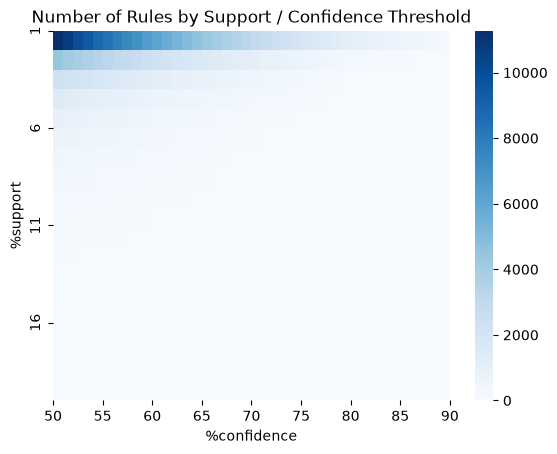

In [39]:
sns.heatmap(len_r, cmap="Blues")
plt.yticks(np.arange(0, max_sup - min_sup + 1, 5), np.arange(min_sup, max_sup + 1, 5))
plt.xticks(np.arange(0, max_conf - min_conf + 1, 5), np.arange(min_conf, max_conf + 1, 5))
plt.xlabel("%confidence")
plt.ylabel("%support")
plt.title("Number of Rules by Support / Confidence Threshold")
plt.show()

## Summary

- Mining is done **only on the training set**; the test set is used exactly once, to evaluate a specific rule chosen from the training data, avoiding leakage between "discovering" patterns and "evaluating" them.
- Bin edges derived from the data (`YearBin`, `PopularityBin`) are fit on the training set and applied unchanged to the test set; bins based on fixed real-world thresholds (players, playtime, `WeightBin`) are applied identically to both since they don't depend on this dataset's distribution.
- `WeightBin` now actually uses the fixed 1/2/3/5 thresholds it was defined with (previously computed with `qcut`, ignoring those thresholds and using dataset-relative terciles instead).
- A bug in the qualitative-rules selection (`'ant': ('WeightBin_Easy')`, a plain string instead of a 1-item tuple `('WeightBin_Easy',)`) has been fixed — the previous version would never have matched that rule correctly.
- Removed unused imports (`copy`, `confusion_matrix`, `train_test_split` — no longer needed now that a real train/test split is used directly), several empty cells, and a large block of commented-out, unused `DecisionTreeClassifier` code at the end. If that classifier is still wanted, it should be a working, executed cell rather than commented-out dead code — happy to build it out properly if useful.

#### Saving the extracted rules

In [40]:
output_path = "../data/association_rules.csv"
rules_df.to_csv(output_path, index=False)
print(f"Saved: {output_path} ({len(rules_df)} rules)")

Saved: ../data/association_rules.csv (198 rules)
